# Block G: Advanced Model - CNN (3-Class NICE Labels)

This notebook trains a 1D CNN on raw CTG windows (`FHR + UC`) using **NICE-derived 3-class labels** (`Normal`, `Suspicious`, `Pathological`) aligned with Block E.


In [1]:
from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'src').exists()), cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import PreprocessConfig, preprocess_fhr, preprocess_uc
from src.utils import fill_nans_for_processing
from src.nice_labels import assign_3class_labels


In [2]:
CLASS_NAMES = ['Normal', 'Suspicious', 'Pathological']
LABEL_TO_IDX = {k: i for i, k in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: k for k, i in LABEL_TO_IDX.items()}

DATA_DIR = PROJECT_ROOT / 'data' / 'ctu-chb-intrapartum-cardiotocography-database-1.0.0'
MANIFEST_CSV = PROJECT_ROOT / 'outputs' / 'segmentation_manifest.csv'
FEATURES_CSV = PROJECT_ROOT / 'outputs' / 'feature_matrix.csv'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)
RF_REPORT = OUT_DIR / 'rf_3class_report.json'

CFG = {
    'seed': 42,
    'fs_expected': 4.0,
    'window_min': 10,
    'batch_size': 64,
    'epochs': 40,
    'lr': 3e-4,
    'weight_decay': 1e-4,
    'dropout': 0.3,
    'patience': 10,
    'num_workers': 2,
    'train_ratio': 0.70,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'grad_clip': 1.0,
    'normalization': 'window_zscore',  # 'window_zscore' or 'global_train'
    'use_weighted_sampler': False,
    'scale_clip': 8.0,
}

PRE_CFG = PreprocessConfig(
    fs_default=4.0,
    fhr_min=80.0,
    fhr_max=240.0,
    fhr_missing_sentinel=0.0,
    uc_min=0.0,
    uc_max=100.0,
    max_interp_gap_sec=30.0,
    gauss_sigma_sec=1.5,
    zscore_per_record=False,
)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:', DATA_DIR.exists(), DATA_DIR)
print('MANIFEST_CSV:', MANIFEST_CSV.exists(), MANIFEST_CSV)
print('FEATURES_CSV:', FEATURES_CSV.exists(), FEATURES_CSV)
print('RF_REPORT:', RF_REPORT.exists(), RF_REPORT)


PROJECT_ROOT: /home/naem-haq/Software-Engineering/CTG
DATA_DIR: True /home/naem-haq/Software-Engineering/CTG/data/ctu-chb-intrapartum-cardiotocography-database-1.0.0
MANIFEST_CSV: True /home/naem-haq/Software-Engineering/CTG/outputs/segmentation_manifest.csv
FEATURES_CSV: True /home/naem-haq/Software-Engineering/CTG/outputs/feature_matrix.csv
RF_REPORT: True /home/naem-haq/Software-Engineering/CTG/outputs/models/rf_3class_report.json


In [3]:
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
torch.cuda.manual_seed_all(CFG['seed'])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cpu


In [4]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest = manifest.loc[manifest['keep_window'] == True].copy()
manifest['record_id'] = manifest['record_id'].astype(str)
manifest['window_idx'] = manifest['window_idx'].astype(int)

feat = pd.read_csv(FEATURES_CSV)
feat['record_id'] = feat['record_id'].astype(str)
feat['window_idx'] = feat['window_idx'].astype(int)
feat['label_3class'] = assign_3class_labels(feat)

labels_df = feat[['record_id', 'window_idx', 'label_3class']].drop_duplicates(['record_id', 'window_idx'])
labels_df = labels_df.loc[labels_df['label_3class'].isin(CLASS_NAMES)].copy()

print('Manifest windows (keep_window=True):', len(manifest))
print('Feature windows:', len(feat))
print('NICE labels distribution:', labels_df['label_3class'].value_counts().to_dict())


Manifest windows (keep_window=True): 29989
Feature windows: 29989
NICE labels distribution: {'Pathological': 17491, 'Suspicious': 8339, 'Normal': 4159}


In [5]:
data = manifest.merge(labels_df, on=['record_id', 'window_idx'], how='left')
missing = int(data['label_3class'].isna().sum())
if missing > 0:
    print(f'Dropping {missing} windows without NICE label after merge.')

data = data.loc[data['label_3class'].isin(CLASS_NAMES)].copy()
data['y'] = data['label_3class'].map(LABEL_TO_IDX).astype(int)

print('Final windows for CNN:', len(data))
print('Window-level classes:', data['label_3class'].value_counts().to_dict())
print('Unique records:', data['record_id'].nunique())


Final windows for CNN: 29989
Window-level classes: {'Pathological': 17491, 'Suspicious': 8339, 'Normal': 4159}
Unique records: 550


In [6]:
record_label = (
    data.groupby(['record_id', 'label_3class']).size().reset_index(name='n')
    .sort_values(['record_id', 'n'], ascending=[True, False])
    .drop_duplicates('record_id')
)
records = record_label[['record_id', 'label_3class']].reset_index(drop=True)

print('Record-level dominant class distribution:', records['label_3class'].value_counts().to_dict())

train_rec, temp_rec = train_test_split(
    records,
    test_size=(1.0 - CFG['train_ratio']),
    random_state=CFG['seed'],
    stratify=records['label_3class'],
)

val_in_temp = CFG['val_ratio'] / (CFG['val_ratio'] + CFG['test_ratio'])
val_rec, test_rec = train_test_split(
    temp_rec,
    test_size=(1.0 - val_in_temp),
    random_state=CFG['seed'],
    stratify=temp_rec['label_3class'],
)

split_map = {}
for rid in train_rec['record_id'].astype(str):
    split_map[rid] = 'train'
for rid in val_rec['record_id'].astype(str):
    split_map[rid] = 'val'
for rid in test_rec['record_id'].astype(str):
    split_map[rid] = 'test'

data['split'] = data['record_id'].map(split_map)
data = data.loc[data['split'].notna()].copy()

split_summary = {
    'random_state': CFG['seed'],
    'ratios': {'train': CFG['train_ratio'], 'val': CFG['val_ratio'], 'test': CFG['test_ratio']},
    'records_per_split': data.groupby('split')['record_id'].nunique().to_dict(),
    'windows_per_split': data['split'].value_counts().to_dict(),
    'class_distribution_windows': data.groupby(['split', 'label_3class']).size().unstack(fill_value=0).to_dict(),
    'record_level_dominant_distribution': records['label_3class'].value_counts().to_dict(),
}

split_summary_path = OUT_DIR / 'cnn_3class_split_summary.json'
split_summary_path.write_text(json.dumps(split_summary, indent=2))
print('Saved:', split_summary_path)


Record-level dominant class distribution: {'Pathological': 405, 'Suspicious': 104, 'Normal': 41}
Saved: /home/naem-haq/Software-Engineering/CTG/outputs/models/cnn_3class_split_summary.json


In [7]:
print('Record counts by split:')
print(data.groupby('split')['record_id'].nunique())
print('\nWindow counts by split and class:')
print(data.groupby(['split', 'label_3class']).size().unstack(fill_value=0))


Record counts by split:
split
test      83
train    384
val       83
Name: record_id, dtype: int64

Window counts by split and class:
label_3class  Normal  Pathological  Suspicious
split                                         
test             668          2550        1198
train           2934         12319        5872
val              557          2622        1269


In [8]:
def find_signal_indices(sig_names):
    upper = [s.upper() for s in sig_names]

    def find(keys):
        for i, name in enumerate(upper):
            for k in keys:
                if k in name:
                    return i
        return None

    fhr_idx = find(['FHR', 'FETAL'])
    uc_idx = find(['UC', 'TOCO', 'UA', 'UTERINE'])
    return fhr_idx, uc_idx

def zscore_fill(x):
    y = np.asarray(x, dtype=np.float32).copy()
    finite = np.isfinite(y)
    if finite.any():
        mu = float(y[finite].mean())
        sd = float(y[finite].std())
        if sd > 0:
            y[finite] = (y[finite] - mu) / sd
        else:
            y[finite] = 0.0
    else:
        y[:] = 0.0
    return fill_nans_for_processing(y).astype(np.float32)

def scale_with_stats(x, mu, sd, clip=8.0):
    y = fill_nans_for_processing(np.asarray(x, dtype=np.float32)).astype(np.float32)
    y = (y - float(mu)) / float(sd)
    return np.clip(y, -clip, clip).astype(np.float32)


In [9]:
class RecordCache:
    def __init__(self, data_dir, pre_cfg):
        self.data_dir = Path(data_dir)
        self.pre_cfg = pre_cfg
        self.cache = {}

    def get(self, record_id):
        rid = str(record_id)
        if rid in self.cache:
            return self.cache[rid]

        rec_path = str((self.data_dir / rid).resolve())
        p_signal, fields = wfdb.rdsamp(rec_path)
        fhr_idx, uc_idx = find_signal_indices(fields.get('sig_name', []))
        if fhr_idx is None or uc_idx is None:
            raise ValueError(f'Missing FHR/UC in record {rid}')

        fs = float(fields.get('fs', self.pre_cfg.fs_default))
        fhr_clean, _ = preprocess_fhr(p_signal[:, fhr_idx], fs=fs, cfg=self.pre_cfg)
        uc_clean, _ = preprocess_uc(p_signal[:, uc_idx], fs=fs, cfg=self.pre_cfg)

        self.cache[rid] = (fhr_clean.astype(np.float32), uc_clean.astype(np.float32), fs)
        return self.cache[rid]

cache = RecordCache(DATA_DIR, PRE_CFG)


In [10]:
WINDOW_SAMPLES = int(CFG['window_min'] * 60 * CFG['fs_expected'])

class CTGDataset(Dataset):
    def __init__(self, frame, cache, window_samples, channel_stats=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.cache = cache
        self.window_samples = window_samples
        self.channel_stats = channel_stats or {}

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        rid = str(row['record_id'])
        start = int(row['start_sample'])
        end = int(row['end_sample'])

        fhr, uc, _ = self.cache.get(rid)
        fhr_w = fhr[start:end]
        uc_w = uc[start:end]

        if CFG['normalization'] == 'global_train':
            fhr_s = scale_with_stats(fhr_w, self.channel_stats['fhr_mean'], self.channel_stats['fhr_std'], clip=CFG['scale_clip'])
            uc_s = scale_with_stats(uc_w, self.channel_stats['uc_mean'], self.channel_stats['uc_std'], clip=CFG['scale_clip'])
        else:
            fhr_s = zscore_fill(fhr_w)
            uc_s = zscore_fill(uc_w)

        x = np.vstack([fhr_s, uc_s])
        if x.shape[1] < self.window_samples:
            pad = self.window_samples - x.shape[1]
            x = np.pad(x, ((0, 0), (0, pad)), mode='edge')
        elif x.shape[1] > self.window_samples:
            x = x[:, :self.window_samples]

        y = int(row['y'])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long), rid


In [11]:
train_df = data.loc[data['split'] == 'train'].copy()
val_df = data.loc[data['split'] == 'val'].copy()
test_df = data.loc[data['split'] == 'test'].copy()

def compute_channel_stats(frame, cache):
    sums = {'fhr': 0.0, 'uc': 0.0}
    sums_sq = {'fhr': 0.0, 'uc': 0.0}
    counts = {'fhr': 0, 'uc': 0}
    for rid in frame['record_id'].astype(str).unique():
        fhr, uc, _ = cache.get(rid)
        fhr_f = fhr[np.isfinite(fhr)]
        uc_f = uc[np.isfinite(uc)]
        if fhr_f.size:
            sums['fhr'] += float(fhr_f.sum())
            sums_sq['fhr'] += float((fhr_f ** 2).sum())
            counts['fhr'] += int(fhr_f.size)
        if uc_f.size:
            sums['uc'] += float(uc_f.sum())
            sums_sq['uc'] += float((uc_f ** 2).sum())
            counts['uc'] += int(uc_f.size)
    stats = {}
    for ch in ['fhr', 'uc']:
        n = max(counts[ch], 1)
        mu = sums[ch] / n
        var = max((sums_sq[ch] / n) - (mu * mu), 1e-6)
        stats[f'{ch}_mean'] = float(mu)
        stats[f'{ch}_std'] = float(np.sqrt(var))
    return stats

channel_stats = compute_channel_stats(train_df, cache)
print('Normalization mode:', CFG['normalization'])
if CFG['normalization'] == 'global_train':
    print('Train-only channel stats:', channel_stats)

train_ds = CTGDataset(train_df, cache, WINDOW_SAMPLES, channel_stats)
val_ds = CTGDataset(val_df, cache, WINDOW_SAMPLES, channel_stats)
test_ds = CTGDataset(test_df, cache, WINDOW_SAMPLES, channel_stats)

if CFG['use_weighted_sampler']:
    class_count_by_idx = train_df['y'].value_counts().to_dict()
    sample_w = train_df['y'].map(lambda y: 1.0 / class_count_by_idx[int(y)]).to_numpy(dtype=np.float64)
    train_sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_w),
        num_samples=len(sample_w),
        replacement=True,
    )
    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=train_sampler, num_workers=CFG['num_workers'])
else:
    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, num_workers=CFG['num_workers'])

val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])

xb, yb, rb = next(iter(train_loader))
print('Batch X shape:', tuple(xb.shape))
print('Batch y shape:', tuple(yb.shape))
print('Example labels:', yb[:10].tolist())


Normalization mode: window_zscore


Batch X shape: (64, 2, 2400)
Batch y shape: (64,)
Example labels: [1, 0, 0, 2, 1, 2, 2, 2, 1, 2]


In [12]:
counts = train_df['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0).astype(float)
class_weights = counts.sum() / (len(CLASS_NAMES) * counts.clip(lower=1.0))
class_weight_t = torch.tensor(class_weights.values, dtype=torch.float32, device=DEVICE)
print('Train class counts:', counts.to_dict())
print('Class weights:', {k: float(v) for k, v in zip(CLASS_NAMES, class_weights.values)})


Train class counts: {'Normal': 2934.0, 'Suspicious': 5872.0, 'Pathological': 12319.0}
Class weights: {'Normal': 2.400022722108612, 'Suspicious': 1.19919391462307, 'Pathological': 0.5716102497497091}


In [13]:
class CTG1DCNN(nn.Module):
    def __init__(self, n_classes=3, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))

model = CTG1DCNN(n_classes=3, dropout=CFG['dropout']).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print('Parameters:', n_params)


CTG1DCNN(
  (features): Sequential(
    (0): Conv1d(2, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3,

In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weight_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])

def collect_metrics(y_true, y_pred):
    labels = [0, 1, 2]
    rep = classification_report(
        y_true, y_pred, labels=labels, target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )
    return {
        'accuracy': float(np.mean(y_true == y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'per_class': {
            name: {
                'precision': float(rep[name]['precision']),
                'recall': float(rep[name]['recall']),
                'f1': float(rep[name]['f1-score']),
                'support': int(rep[name]['support']),
            } for name in CLASS_NAMES
        },
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=labels).tolist(),
    }

def run_epoch(model, loader, train=False):
    model.train(train)
    losses, yt, yp, probs, rids = [], [], [], [], []

    for xb, yb, rid in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            optimizer.step()

        p = torch.softmax(logits, dim=1)
        pred = torch.argmax(p, dim=1)

        losses.append(float(loss.detach().cpu().item()))
        yt.append(yb.detach().cpu().numpy())
        yp.append(pred.detach().cpu().numpy())
        probs.append(p.detach().cpu().numpy())
        rids.extend([str(x) for x in rid])

    yt = np.concatenate(yt) if yt else np.array([], dtype=int)
    yp = np.concatenate(yp) if yp else np.array([], dtype=int)
    probs = np.concatenate(probs) if probs else np.zeros((0, 3), dtype=float)
    return float(np.mean(losses)), yt, yp, probs, rids


In [15]:
history = []
best_epoch = -1
best_val_f1 = -1.0
best_state = None
wait = 0

for epoch in range(1, CFG['epochs'] + 1):
    train_loss, ytr, ptr, _, _ = run_epoch(model, train_loader, train=True)
    val_loss, yva, pva, _, _ = run_epoch(model, val_loader, train=False)
    scheduler.step()

    train_f1 = float(f1_score(ytr, ptr, labels=[0, 1, 2], average='macro', zero_division=0))
    val_f1 = float(f1_score(yva, pva, labels=[0, 1, 2], average='macro', zero_division=0))

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_macro_f1': train_f1,
        'val_macro_f1': val_f1,
        'lr': float(optimizer.param_groups[0]['lr']),
    })

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_f1={train_f1:.4f} val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if wait >= CFG['patience']:
        print('Early stopping triggered.')
        break

model.load_state_dict(best_state)
model_path = OUT_DIR / 'cnn_3class_model.pt'
torch.save({'model_state_dict': model.state_dict(), 'cfg': CFG, 'label_map': LABEL_TO_IDX}, model_path)

history_df = pd.DataFrame(history)
history_csv = OUT_DIR / 'cnn_3class_history.csv'
history_df.to_csv(history_csv, index=False)

print('Best epoch:', best_epoch)
print('Best val macro-F1:', round(best_val_f1, 4))
print('Saved model:', model_path)


Epoch 01 | train_loss=0.9689 val_loss=0.9054 train_f1=0.4816 val_f1=0.5452


Epoch 02 | train_loss=0.9081 val_loss=0.9145 train_f1=0.5341 val_f1=0.4910


Epoch 03 | train_loss=0.8880 val_loss=0.8771 train_f1=0.5458 val_f1=0.5481


Epoch 04 | train_loss=0.8834 val_loss=0.8668 train_f1=0.5494 val_f1=0.5610


Epoch 05 | train_loss=0.8738 val_loss=0.8977 train_f1=0.5601 val_f1=0.5324


...

Epoch 14 | train_loss=0.8504 val_loss=0.8643 train_f1=0.5717 val_f1=0.5428


Epoch 15 | train_loss=0.8466 val_loss=0.8474 train_f1=0.5723 val_f1=0.5533


Epoch 16 | train_loss=0.8448 val_loss=0.8592 train_f1=0.5744 val_f1=0.5535


Epoch 17 | train_loss=0.8474 val_loss=0.8624 train_f1=0.5713 val_f1=0.5546


Epoch 18 | train_loss=0.8448 val_loss=0.8567 train_f1=0.5758 val_f1=0.5484
Early stopping triggered.
Best epoch: 8
Best val macro-F1: 0.5628
Saved model: /home/naem-haq/Software-Engineering/CTG/outputs/models/cnn_3class_model.pt


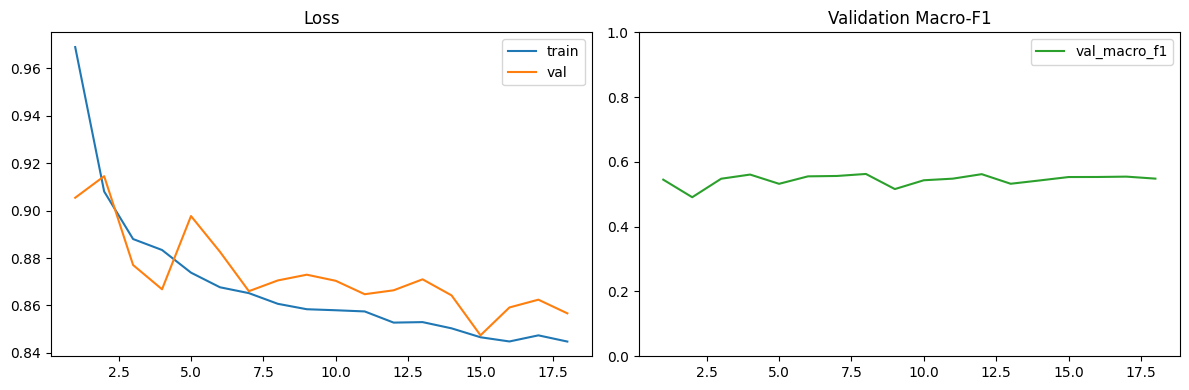

Saved: /home/naem-haq/Software-Engineering/CTG/outputs/models/cnn_3class_training_curves.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_macro_f1'], label='val_macro_f1', color='tab:green')
axes[1].set_title('Validation Macro-F1')
axes[1].set_ylim(0, 1)
axes[1].legend()

fig.tight_layout()
curves_png = OUT_DIR / 'cnn_3class_training_curves.png'
fig.savefig(curves_png, dpi=180)
plt.show()
print('Saved:', curves_png)


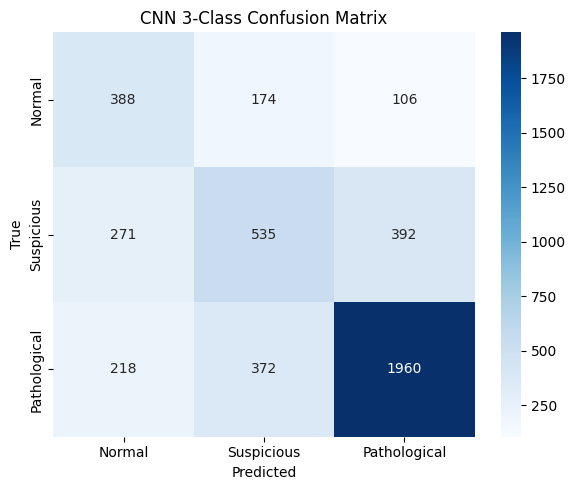

Window-level accuracy: 0.6529
Window-level macro-F1: 0.5848
Pathological recall: 0.7686
Saved: /home/naem-haq/Software-Engineering/CTG/outputs/models/cnn_3class_confusion_matrix.png


In [17]:
test_loss, yte, pte, probs_te, rid_te = run_epoch(model, test_loader, train=False)
window_metrics = collect_metrics(yte, pte)

cm = np.array(window_metrics['confusion_matrix'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('CNN 3-Class Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
fig.tight_layout()
cm_png = OUT_DIR / 'cnn_3class_confusion_matrix.png'
fig.savefig(cm_png, dpi=180)
plt.show()

print('Window-level accuracy:', round(window_metrics['accuracy'], 4))
print('Window-level macro-F1:', round(window_metrics['macro_f1'], 4))
print('Pathological recall:', round(window_metrics['per_class']['Pathological']['recall'], 4))
print('Saved:', cm_png)


In [18]:
eval_df = pd.DataFrame({
    'record_id': rid_te,
    'y_true': yte,
    'p0': probs_te[:, 0],
    'p1': probs_te[:, 1],
    'p2': probs_te[:, 2],
})

record_prob = eval_df.groupby('record_id', as_index=False).agg(
    y_true=('y_true', 'first'),
    p0=('p0', 'mean'),
    p1=('p1', 'mean'),
    p2=('p2', 'mean'),
)
record_pred = np.argmax(record_prob[['p0', 'p1', 'p2']].to_numpy(), axis=1)
record_metrics = collect_metrics(record_prob['y_true'].to_numpy(dtype=int), record_pred)

report = {
    'metadata': {
        'notebook': '07-BlockG-CNN',
        'objective': '3-class CTG CNN using NICE-derived labels from feature_matrix',
        'device': str(DEVICE),
        'random_state': CFG['seed'],
        'best_epoch': int(best_epoch),
        'class_labels': CLASS_NAMES,
    },
    'config': CFG,
    'dataset': {
        'total_windows': int(len(data)),
        'train_windows': int(len(train_df)),
        'val_windows': int(len(val_df)),
        'test_windows': int(len(test_df)),
        'train_records': int(train_df['record_id'].nunique()),
        'val_records': int(val_df['record_id'].nunique()),
        'test_records': int(test_df['record_id'].nunique()),
    },
    'train_history': {
        'history_csv': str(history_csv),
        'best_val_macro_f1': float(best_val_f1),
        'last_epoch': int(history_df['epoch'].max()),
    },
    'window_level': {'loss': float(test_loss), **window_metrics},
    'record_level': record_metrics,
    'artifacts': {
        'model': str(model_path),
        'split_summary': str(split_summary_path),
        'training_curves': str(curves_png),
        'confusion_matrix': str(cm_png),
    },
}

report_path = OUT_DIR / 'cnn_3class_report.json'
report_path.write_text(json.dumps(report, indent=2))

comparison = None
if RF_REPORT.exists():
    rf = json.loads(RF_REPORT.read_text())
    rf_perf = rf.get('performance', {})
    rf_acc = float(rf_perf.get('overall_accuracy', np.nan))
    rf_macro = float(np.nanmean([rf_perf.get('per_class_metrics', {}).get(c, {}).get('f1', np.nan) for c in CLASS_NAMES]))

    comparison = {
        'rf': {'accuracy': rf_acc, 'macro_f1': rf_macro},
        'cnn': {'accuracy': float(window_metrics['accuracy']), 'macro_f1': float(window_metrics['macro_f1'])},
        'delta_cnn_minus_rf': {
            'accuracy': float(window_metrics['accuracy'] - rf_acc),
            'macro_f1': float(window_metrics['macro_f1'] - rf_macro),
        },
    }
    compare_path = OUT_DIR / 'cnn_vs_rf_comparison.json'
    compare_path.write_text(json.dumps(comparison, indent=2))
    print('Saved:', compare_path)

print('Saved:', report_path)
print('Record-level macro-F1:', round(record_metrics['macro_f1'], 4))
if comparison is not None:
    print('CNN vs RF delta macro-F1:', round(comparison['delta_cnn_minus_rf']['macro_f1'], 4))


Saved: /home/naem-haq/Software-Engineering/CTG/outputs/models/cnn_vs_rf_comparison.json
Saved: /home/naem-haq/Software-Engineering/CTG/outputs/models/cnn_3class_report.json
Record-level macro-F1: 0.3877
CNN vs RF delta macro-F1: -0.3604


## Final Notes

- This notebook uses the same NICE 3-class target definition as Block E (via `assign_3class_labels`).
- Split stratification is done at record level using each record's dominant window class.
- Normalization and sampling are configurable (`CFG['normalization']`, `CFG['use_weighted_sampler']`) for controlled ablation runs.
